In [1]:
import pandas as pd
import numpy as np

summary_15x = pd.read_csv(f"merged_summary_15x.csv")
summary_30x = pd.read_csv(f"merged_summary_30x.csv")
summary_all = pd.read_csv(f"merged_summary_all.csv")

In [2]:
local_30x_num = 310
local_15x_num = 1441
local_30x_freq = local_30x_num / (local_30x_num + local_15x_num)
local_15x_freq = local_15x_num / (local_30x_num + local_15x_num)

In [3]:
def compute_observed_expected_metric(summary_all, summary_15x, summary_30x, metric, weight_15x=0.5, weight_30x=0.5):
    """
    输入：
        - summary_all, summary_15x, summary_30x: 含有 (DP, GQ, LAF, HAF, metric) 的 DataFrame
        - metric: str，列名，如 'GENOTYPE_CONCORDANCE'
        - weight_15x, weight_30x: 两个平台的加权权重，和应为1.0

    输出：
        - 一个 DataFrame，包含：
            - 'DP', 'GQ', 'LAF', 'HAF'
            - f'OBSERVED_f{metric}': 来自 summary_all
            - f'EXPECTED_f{metric}': 来自 summary_15x 和 summary_30x 的加权平均
    """
    key_cols = ['DP', 'GQ', 'LAF', 'HAF']
    
    # 保证 metric 列存在
    for df_name, df in [('summary_all', summary_all), ('summary_15x', summary_15x), ('summary_30x', summary_30x)]:
        if metric not in df.columns:
            raise ValueError(f"Column '{metric}' not found in {df_name}.")

    # 提取各表中需要的列
    all_df = summary_all[key_cols + [metric]].copy()
    df_15x = summary_15x[key_cols + [metric]].copy().rename(columns={metric: "metric_15x"})
    df_30x = summary_30x[key_cols + [metric]].copy().rename(columns={metric: "metric_30x"})

    # 合并三个表
    merged = all_df.merge(df_15x, on=key_cols, how='left')
    merged = merged.merge(df_30x, on=key_cols, how='left')

    # 计算期望值
    expected_col = f"EXPECTED_{metric}"
    observed_col = f"OBSERVED_{metric}"
    merged[expected_col] = (
        weight_15x * merged["metric_15x"] + weight_30x * merged["metric_30x"]
    )
    merged[observed_col] = merged[metric]

    # 只保留需要的列
    result = merged[key_cols + [observed_col, expected_col]].copy()

    return result

metrics = [
    'GENOTYPE_CONCORDANCE',
    'GENOTYPE_MISS_RATE',
    'FALSE_POSITIVE_RATE',
    'FALSE_NEGATIVE_RATE'
]

observed_expected_results = {}

for metric in metrics:
    observed_expected_results[metric] = compute_observed_expected_metric(
        summary_all=summary_all,
        summary_15x=summary_15x,
        summary_30x=summary_30x,
        metric=metric,
        weight_15x=local_15x_freq,
        weight_30x=local_30x_freq
    )


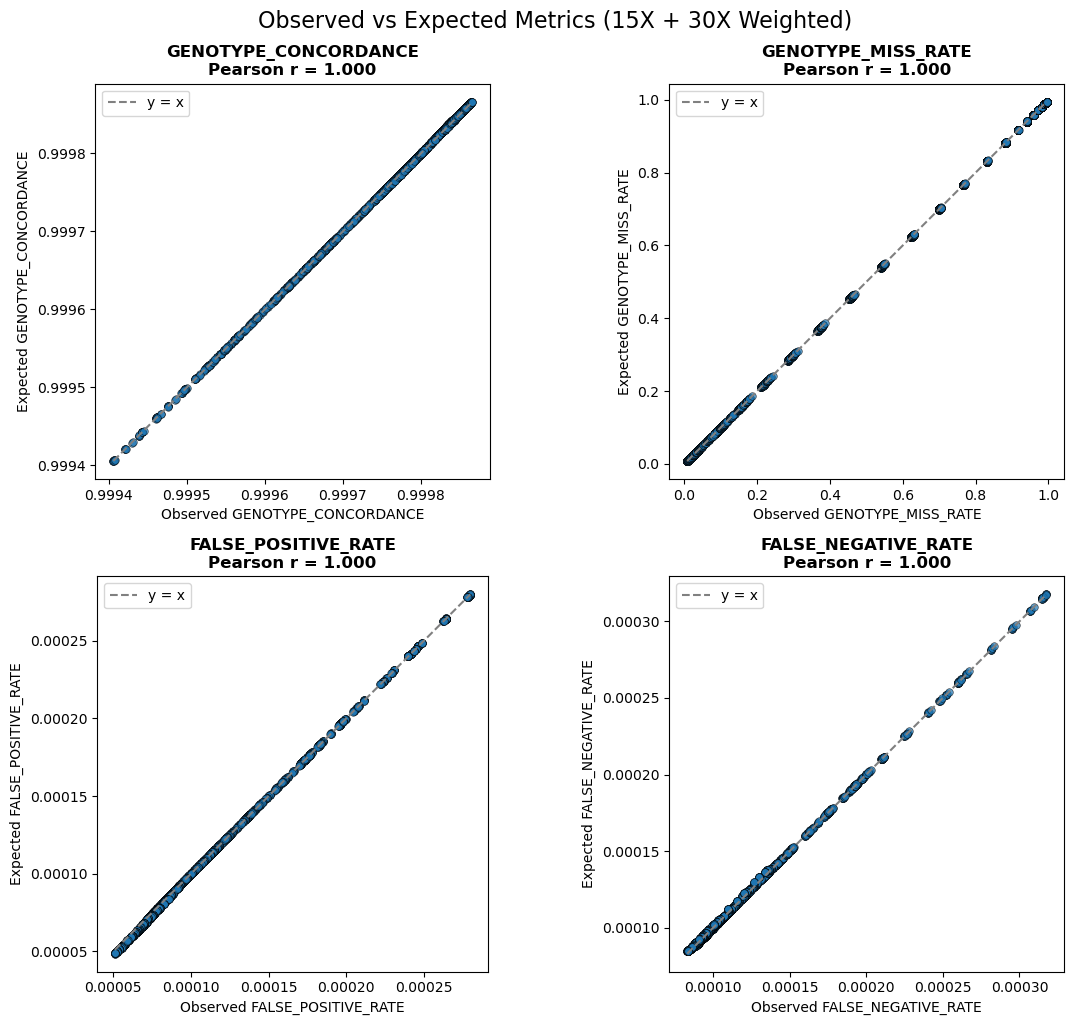

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def plot_observed_vs_expected_grid(results_dict, metrics):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        df = results_dict[metric]
        x_col = f'OBSERVED_{metric}'
        y_col = f'EXPECTED_{metric}'
        
        # 去除缺失值
        df_clean = df[[x_col, y_col]].dropna()
        x = df_clean[x_col]
        y = df_clean[y_col]

        # 计算皮尔逊相关系数 r
        r, pval = pearsonr(x, y)
        
        # 绘图
        ax = axes[i]
        sns.scatterplot(x=x, y=y, ax=ax, s=30, alpha=0.7, edgecolor='black')
        ax.plot([x.min(), x.max()], [x.min(), x.max()], linestyle='--', color='gray', label='y = x')

        ax.set_title(f"{metric}\nPearson r = {r:.3f}", fontsize=12, fontweight='bold')
        ax.set_xlabel(f"Observed {metric}")
        ax.set_ylabel(f"Expected {metric}")
        ax.set_aspect('equal', adjustable='box')
        ax.legend()

    plt.style.use('default')
    plt.tight_layout()
    plt.suptitle("Observed vs Expected Metrics (15X + 30X Weighted)", fontsize=16, y=1.02)
    plt.show()

plot_observed_vs_expected_grid(observed_expected_results, metrics)

In [6]:
global_30x_num = 383
global_15x_num = 3166
global_30x_freq = global_30x_num / (global_30x_num + global_15x_num)
global_15x_freq = global_15x_num / (global_30x_num + global_15x_num)

In [7]:
def compute_global_estimated_summary(summary_30x, summary_15x, metrics, global_30x_freq, global_15x_freq):
    key_cols = ['DP', 'GQ', 'LAF', 'HAF']
    
    # 重命名 metrics 以避免冲突
    df_30x = summary_30x[key_cols + metrics].copy().rename(columns={m: f"{m}_30x" for m in metrics})
    df_15x = summary_15x[key_cols + metrics].copy().rename(columns={m: f"{m}_15x" for m in metrics})
    
    # 合并两个平台的数据
    merged = df_30x.merge(df_15x, on=key_cols, how='inner')

    # 加权平均计算
    estimated = merged[key_cols].copy()
    for m in metrics:
        estimated[m] = (
            global_30x_freq * merged[f"{m}_30x"] +
            global_15x_freq * merged[f"{m}_15x"]
        )
    
    # 添加 PLATFORM 列
    estimated["PLATFORM"] = "Global Estimation"

    # 调整列顺序
    output_cols = key_cols + ['PLATFORM'] + metrics
    return estimated[output_cols]

metrics = ['GENOTYPE_CONCORDANCE', 'GENOTYPE_MISS_RATE', 'FALSE_POSITIVE_RATE', 'FALSE_NEGATIVE_RATE']

summary_estimated = compute_global_estimated_summary(
    summary_30x=summary_30x,
    summary_15x=summary_15x,
    metrics=metrics,
    global_30x_freq=global_30x_freq,
    global_15x_freq=global_15x_freq
)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from kneed import KneeLocator
from fractions import Fraction

# === Step 1: Identify Pareto Front ===
def find_pareto_front(df, metric1_col, metric2_col, maximize_metric1=True, maximize_metric2=False):
    m1 = df[metric1_col].values
    m2 = df[metric2_col].values
    is_efficient = np.ones(len(df), dtype=bool)
    for i in range(len(df)):
        if is_efficient[i]:
            better_m1 = m1 >= m1[i] if maximize_metric1 else m1 <= m1[i]
            better_m2 = m2 >= m2[i] if maximize_metric2 else m2 <= m2[i]
            strictly_better_m1 = m1 > m1[i] if maximize_metric1 else m1 < m1[i]
            strictly_better_m2 = m2 > m2[i] if maximize_metric2 else m2 < m2[i]
            is_dominated = (better_m1 & better_m2) & (strictly_better_m1 | strictly_better_m2)
            is_dominated[i] = False
            if np.any(is_dominated):
                is_efficient[i] = False
    return pd.Series(is_efficient, index=df.index)

# === Step 2: Kneedle Tradeoff Point Detection ===
def find_kneedle_tradeoff_point(df, x_col, y_col, curve, direction, S, weight_x, weight_y):
    df_unique = df[[x_col, y_col, 'DP', 'GQ', 'LAF', 'HAF']].drop_duplicates().sort_values(by=x_col)
    x = df_unique[x_col].values
    y = df_unique[y_col].values

    kneedle = KneeLocator(x, y, curve=curve, direction=direction, S=S, weight_x=weight_x, weight_y=weight_y)

    if kneedle.knee is not None:
        knee_indices = np.where(x == kneedle.knee)[0]
        if len(knee_indices) > 0:
            knee_index = knee_indices[0]
            return (*df_unique.iloc[knee_index][[x_col, y_col, 'DP', 'GQ', 'LAF', 'HAF']], kneedle)
    return (None, None, None, None, None, None, kneedle)

# === Step 3–5: Main Pipeline ===
def run_pareto_kneedle_pipeline(summary, metric1_col, metric2_col, maximize_metric1, maximize_metric2,
                                 weights, curve, direction):
    # summary[metric1_col] = summary[metric1_col].round(5)
    # summary[metric2_col] = summary[metric2_col].round(5)

    pareto_mask = find_pareto_front(summary, metric1_col, metric2_col, maximize_metric1, maximize_metric2)
    pareto_df_sorted = summary[pareto_mask].sort_values(by=metric2_col if not maximize_metric2 else f"-{metric2_col}")

    plt.close('all')
    fig, axes = plt.subplots(4, 3, figsize=(15, 18))
    
    # === 提取 PLATFORM 主标题 ===
    platform_values = summary['PLATFORM'].unique()
    platform_label = ', '.join(sorted(platform_values))
    fig.suptitle(f"Trade-off Optimization of Genotype Quality in Auto Chr — Platform:{platform_label}",
                 fontsize=14, fontweight='bold', y=1.01)

    for i, weight1 in enumerate(weights):
        weight_x = 1.0
        weight_y = weight1
        ax = axes[i // 3, i % 3]

        x_k, y_k, dp_k, gq_k, laf_k, haf_k, kneedle_obj = find_kneedle_tradeoff_point(
            pareto_df_sorted, x_col=metric2_col, y_col=metric1_col,
            curve=curve, direction=direction, S=1.0,
            weight_x=weight_x, weight_y=weight_y
        )

        ax.scatter(summary[metric2_col], summary[metric1_col], c='lightgray', s=15, label='Dominated Solutions')
        ax.scatter(pareto_df_sorted[metric2_col], pareto_df_sorted[metric1_col], c='red', s=15, label='Nondominated Solutions')
        ax.plot(pareto_df_sorted[metric2_col], pareto_df_sorted[metric1_col], 'r--')

        if x_k is not None:
            ax.scatter(x_k, y_k, color='purple', s=100, marker='D', label='Kneedle Point')

            distances = np.sqrt((summary[metric2_col] - x_k) ** 2 + (summary[metric1_col] - y_k) ** 2)
            nearest_idx = distances.idxmin()
            x_nearest = summary.loc[nearest_idx, metric2_col]
            y_nearest = summary.loc[nearest_idx, metric1_col]

            ax.annotate(
                f"{metric2_col}:{x_nearest:.3%}\n{metric1_col}:{y_nearest:.3%}",
                xy=(x_nearest, y_nearest),
                xytext=(10, -10),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="gray", alpha=0.7)
            )

            ax.set_title(f"W({metric1_col} / {metric2_col}): {Fraction(weight1).limit_denominator()}\n"
                         f"Recommended: DP={dp_k}, GQ={gq_k}, LAF={laf_k}, HAF={haf_k}", fontsize=10, fontweight='bold')
        else:
            ax.set_title(f"Weight Ratio: {Fraction(weight1).limit_denominator()}\nNo Kneedle Point",
                         fontsize=10, fontweight='bold')

        xlabel_arrow = "↑" if maximize_metric2 else "↓"
        ylabel_arrow = "↑" if maximize_metric1 else "↓"
        ax.set_xlabel(f"{metric2_col} {xlabel_arrow}", fontsize=10)
        ax.set_ylabel(f"{metric1_col} {ylabel_arrow}", fontsize=10)

        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8)

    plt.style.use('default')
    plt.tight_layout()
    plt.show()

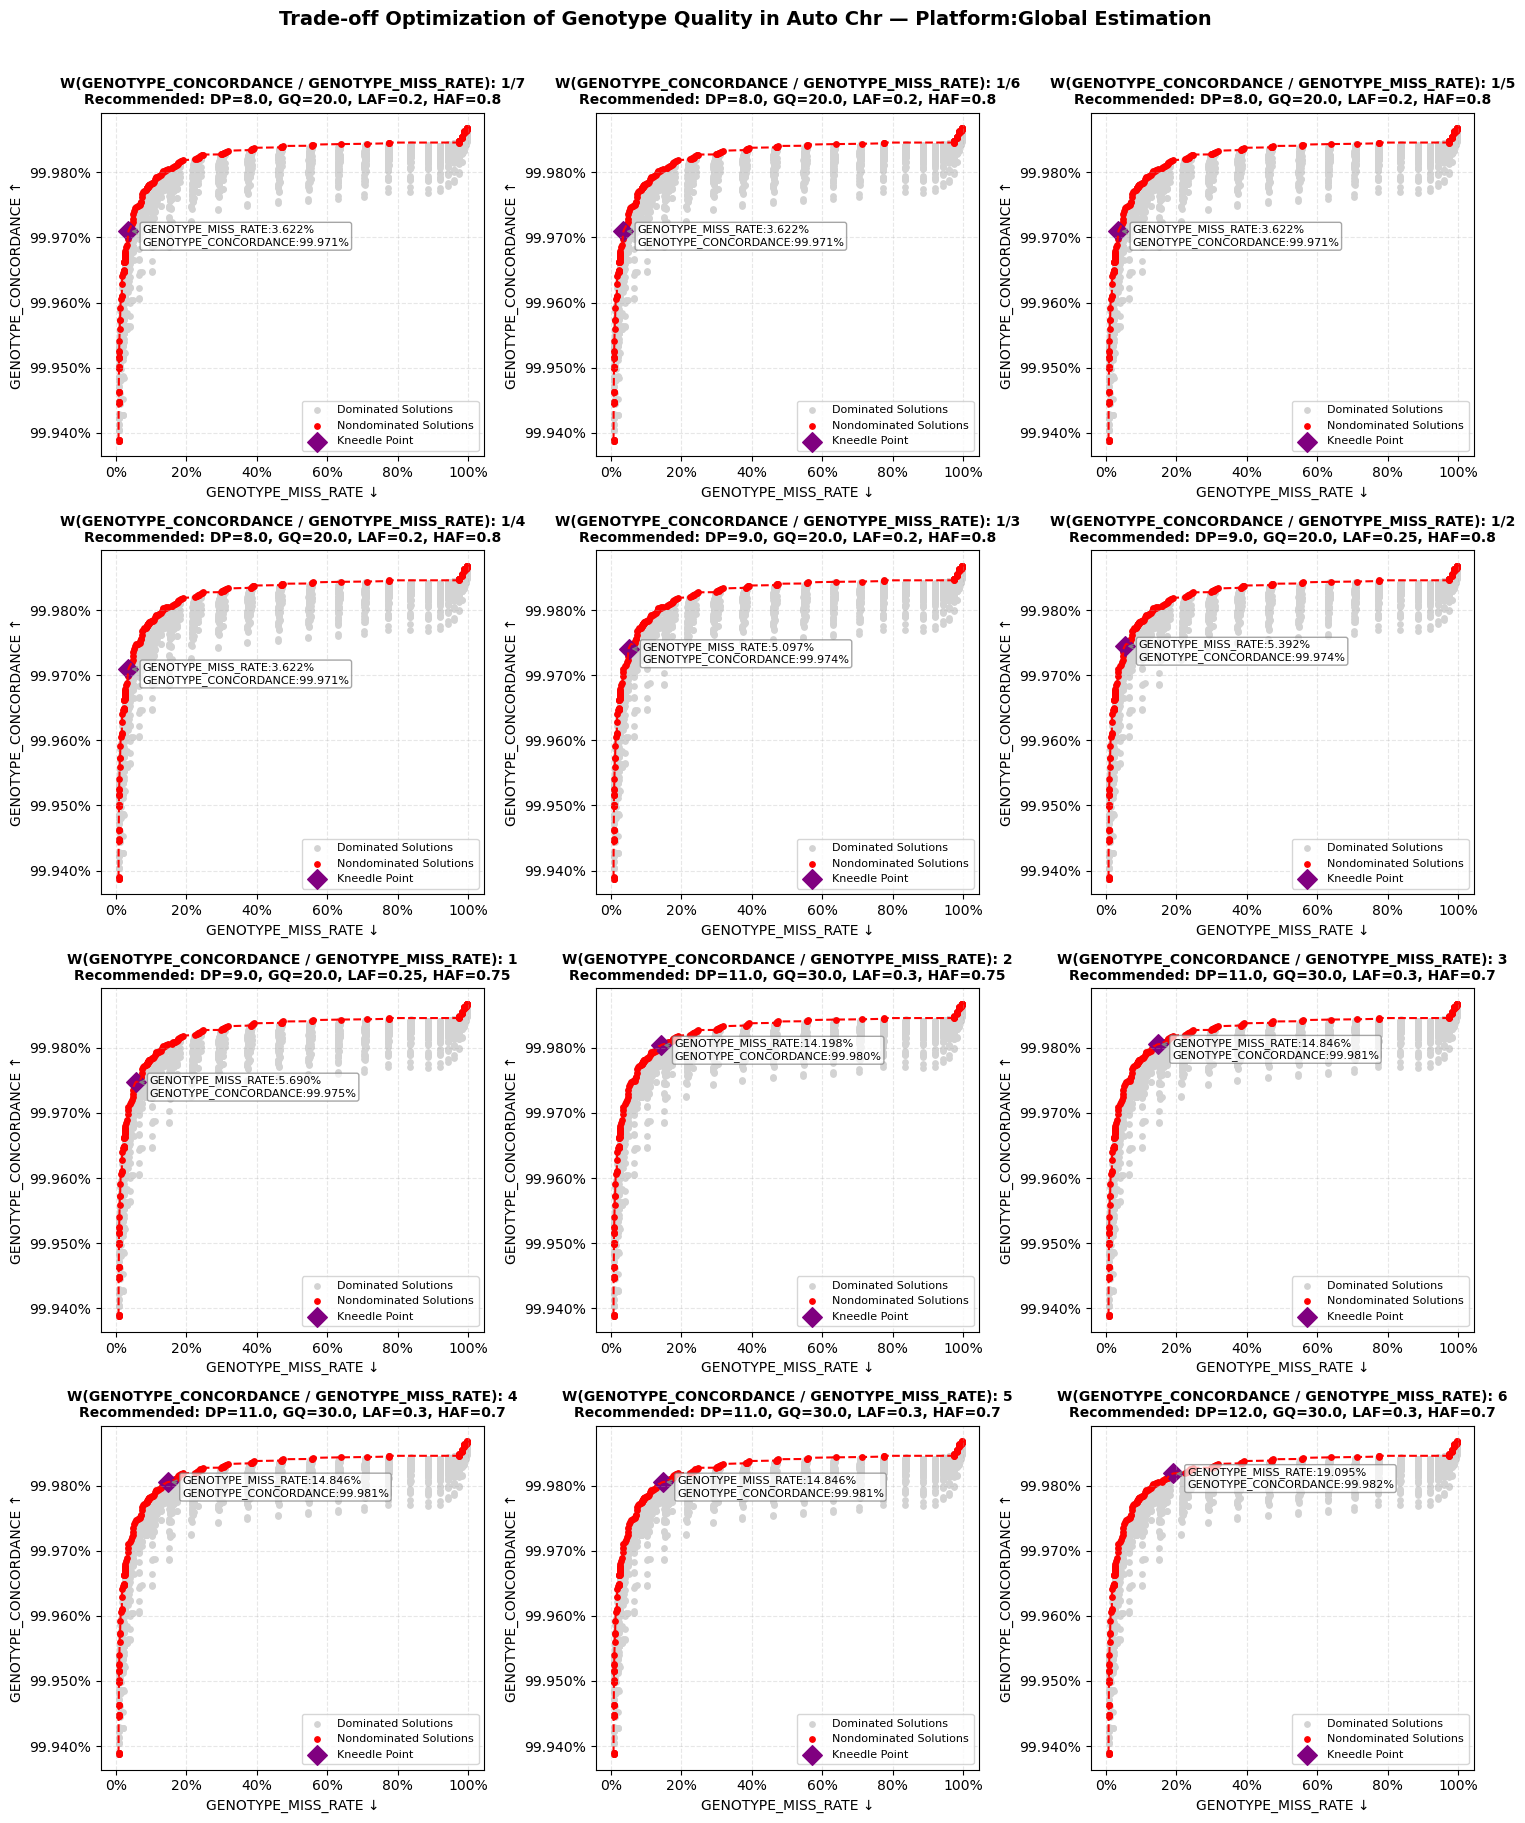

In [9]:
run_pareto_kneedle_pipeline(
    summary=summary_estimated,
    metric1_col='GENOTYPE_CONCORDANCE',
    metric2_col='GENOTYPE_MISS_RATE',
    maximize_metric1=True,
    maximize_metric2=False,
    weights=[1/7, 1/6, 1/5, 1/4, 1/3, 1/2, 1, 2, 3, 4, 5, 6],
    curve='concave',
    direction='increasing'
)